In [ ]:
######################### SK with Parallel Tempering ###################


import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from joblib import Parallel, delayed


# we define a function that selects an inverse-temp schedule that ensures uniform probability of swap acceptance --> good mixing among replicas

def schedule_selection(initial_beta, num_stored_configurations_per_chain, learning_rate,num_independent_chains, minimum_energy_standard_deviation, J, num_nodes, num_sweeps):
    beta_schedule = [initial_beta]
    starting_std = 1000
    chain_system = np.zeros([num_independent_chains, num_stored_configurations_per_chain,  num_nodes])


    chain_system[:, :, :] = np.random.choice([-1,1], size=(num_independent_chains,num_stored_configurations_per_chain, num_nodes))
    energy_system = np.zeros([num_independent_chains, num_stored_configurations_per_chain])

    iteration=0

    while (starting_std>minimum_energy_standard_deviation): 
        
        if iteration !=0:
            beta_new = beta_schedule[iteration-1] + learning_rate/starting_std
            beta_schedule.append(beta_new)

        # take the final state configuration and evolve it
        chain_system[:, :, :] = Parallel(n_jobs=-1)(delayed(MCMC_moves_preliminary)(num_nodes,J, chain_system[chain, -1, :].copy(), num_stored_configurations_per_chain, num_sweeps, beta_schedule[iteration]) for chain in range(num_independent_chains))

        

        # calculate the average energy standard deviation
        energy_system = Parallel(n_jobs=-1)(delayed(energy_function_preliminary)(chain_system[chain, :, :].copy(),J, num_nodes) for chain in range(num_independent_chains))

        # take the std across axis=1, and then the average
        print(starting_std)
        starting_std = np.mean(np.std(energy_system, axis=1))
        

        iteration +=1
        

    return(np.array(beta_schedule))



def MCMC_moves_preliminary(num_nodes,J, replica_state,num_stored_configurations_per_chain, num_sweeps, beta):
    stored_replicas_per_chain = np.zeros([num_sweeps, num_nodes])

    for sweep in range(num_sweeps):
        # local MCMC moves within a fixed beta replica
        for node in range(num_nodes):
            I = np.dot(J[node,:], replica_state)/np.sqrt(num_nodes)
            p_plus = 0.5 * (1 + np.tanh(beta * I))
            replica_state[node] = 1 if np.random.rand() < p_plus else -1
        
        stored_replicas_per_chain[sweep, :] = replica_state

    return(stored_replicas_per_chain[-num_stored_configurations_per_chain:, :])


# def energy_function_preliminary(states_per_chain, J, num_nodes):
#     return(-0.5/np.sqrt(num_nodes)*np.diag(states_per_chain.dot(J).dot(states_per_chain.T)))

def energy_function_preliminary(states_per_chain, J, num_nodes):
    return -0.5 / np.sqrt(num_nodes) * np.einsum(
        "bi,ij,bj->b",
        states_per_chain,
        J,
        states_per_chain
    )


initial_beta = 0
# beta_schedule = np.linspace(0.1, 5, num_replicas)
num_sweeps = 1000
num_nodes = 30
num_independent_chains = 100
minimum_energy_standard_deviation = 0.2
num_stored_configurations_per_chain = 1000 # those are the last 100 sweeps in each chain
learning_rate = 0.35
## generate an SK instance
edges = list(combinations(np.arange(num_nodes), 2))
J = np.zeros([num_nodes, num_nodes])
for (i,j) in edges:
    J[i,j] = np.random.normal(0,1)
    J[j,i] = J[i,j]



beta_schedule = schedule_selection(initial_beta, num_stored_configurations_per_chain, learning_rate,num_independent_chains, minimum_energy_standard_deviation, J, num_nodes, num_sweeps)

num_replicas = len(beta_schedule)

1000
3.8690450063304254
3.854835494718703
3.8314215378953373
3.7548443146627237
3.701478347140349
3.6171246316998547
3.504992675577742
3.389668731043305
3.233046185653902
3.0493842010480496
2.8500359829595534
2.617821812288694
2.3671607620049584
2.1005647697710854
1.8338656281047943
1.5617076306519007
1.3236011958196203
1.0913705727717982
0.8756392857172844
0.6804334120164077
0.5096760569103419
0.37925994175496647
0.2777306519733591


[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
[0.         0.0904616  0.18125665 0.27260656 0.36581948 0.46037629
 0.55713824 0.65699579 0.76025072 0.86850776 0.98328503 1.10609049
 1.23978943 1.38764589 1.55426775 1.74512142 1.96923507 2.23366518
 2.55436285 2.95407082 3.46844885 4.15515955 5.07800945 6.33822325]


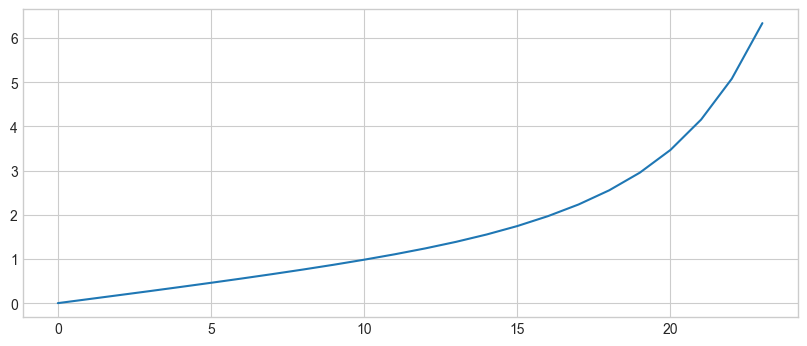

In [38]:
plt.figure(figsize=(10,4))
plt.plot(np.arange(len(beta_schedule), dtype=int), beta_schedule)


print(np.arange(len(beta_schedule), dtype=int))
print(beta_schedule)

In [39]:


##################################### Actual Parallel Tempering Algorithm #######################
num_local_moves_per_swap = 100 # sweep to swap ratio
num_sweeps = 1000
num_swaps = num_sweeps//num_local_moves_per_swap

### Building the adjacent replicas... 
if num_replicas%2 == 0:
    adjacent_replicas_odd_sweep = [(i, i+1) for i in range(0,num_replicas, 2)]
    adjacent_replicas_even_sweep = [(i, i+1) for i in range(1,num_replicas-1, 2)]
else:
    adjacent_replicas_odd_sweep = [(i, i+1) for i in range(0,num_replicas-1, 2)]
    adjacent_replicas_even_sweep = [(i, i+1) for i in range(1,num_replicas-1, 2)]



entire_system =  np.zeros([num_replicas, num_swaps+1, num_nodes])

entire_system[:, 0, :] = np.random.choice([-1,1], (num_replicas, num_nodes))

# diagnostics for the PT swaps and the motion of replicas across beta values
swap_attempts = np.zeros(num_replicas-1, dtype=int)
swap_accepts = np.zeros(num_replicas-1, dtype=int)
p_swap_history = np.full([num_swaps+1, num_replicas-1], np.nan)
swap_success_history = np.full([num_swaps+1, num_replicas-1], np.nan)
replica_id_at_beta = np.zeros([num_swaps+1, num_replicas], dtype=int)
replica_id_at_beta[0, :] = np.arange(num_replicas)


def MCMC_moves(num_nodes,J, replica_state, num_local_moves_per_swap, beta):
    
    for _ in range(num_local_moves_per_swap):
        # local MCMC moves within a fixed beta replica
        for node in range(num_nodes):
            I = np.dot(J[node,:], replica_state)/np.sqrt(num_nodes)
            p_plus = 0.5 * (1 + np.tanh(beta * I))
            replica_state[node] = 1 if np.random.rand() < p_plus else -1
            


    return(replica_state)

def energy_function(state, J):
    return(-0.5/np.sqrt(num_nodes)*state.dot(J).dot(state))


for swap in range(1, num_swaps+1):

    # apply num_local_moves_per_swap MCMC moves for each replica... // Parallelizable 
    entire_system[:,swap,:] = Parallel(n_jobs=-1)(delayed(MCMC_moves)(num_nodes,J, entire_system[replica, swap-1,:].copy(), num_local_moves_per_swap, beta_schedule[replica]) for replica in range(num_replicas))
    replica_id_at_beta[swap, :] = replica_id_at_beta[swap-1, :]

    # Attempt swaps using alternating adjacent pairs
    if swap%2==0: # even swap
        adjacent_pairs = adjacent_replicas_even_sweep
    else: # odd swap
        adjacent_pairs = adjacent_replicas_odd_sweep
        
    for replica_i, replica_j in adjacent_pairs:
        energy_replica_i = energy_function(entire_system[replica_i,swap,:], J)
        energy_replica_j = energy_function(entire_system[replica_j,swap,:], J)

        Delta_E = energy_replica_i-energy_replica_j
        Delta_beta = beta_schedule[replica_i]-beta_schedule[replica_j]
        
        p_swap = min(1, np.exp(Delta_beta*Delta_E)) 
        pair_index = replica_i
        swap_attempts[pair_index] += 1
        p_swap_history[swap, pair_index] = p_swap
        swap_success_history[swap, pair_index] = 0

        if np.random.uniform() < p_swap:
            # accept the swap
            entire_system[[replica_i, replica_j], swap, :] = entire_system[[replica_j, replica_i], swap, :]
            replica_id_at_beta[swap, [replica_i, replica_j]] = replica_id_at_beta[swap, [replica_j, replica_i]]
            swap_accepts[pair_index] += 1
            swap_success_history[swap, pair_index] = 1


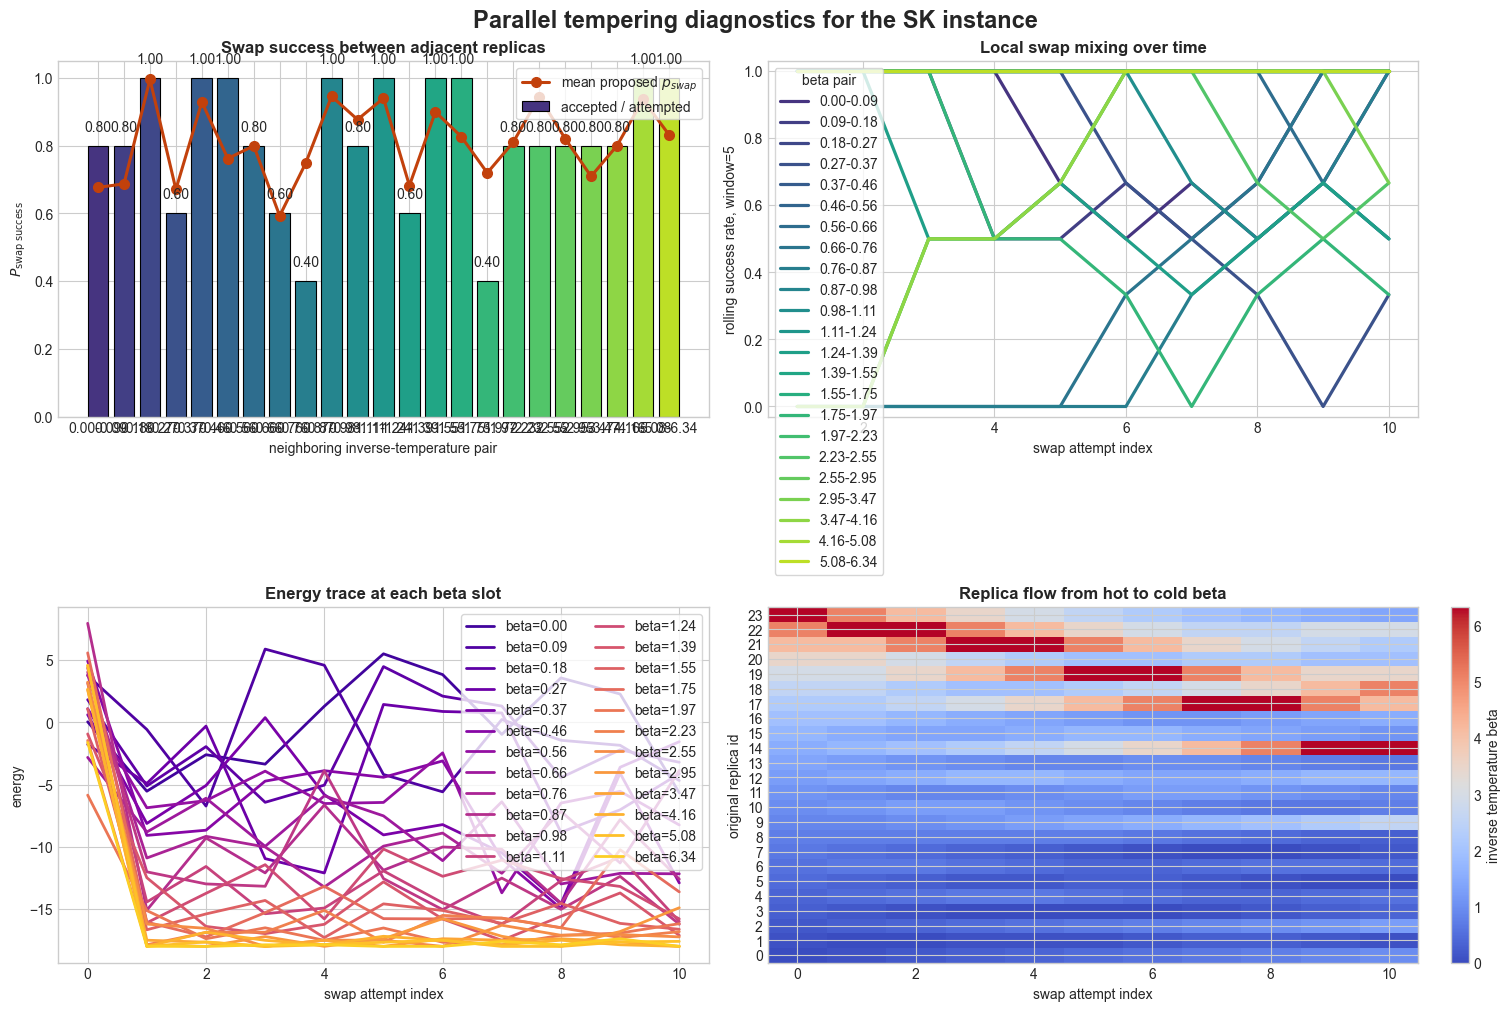

Swap attempts by adjacent beta pair: {'0.00-0.09': 5, '0.09-0.18': 5, '0.18-0.27': 5, '0.27-0.37': 5, '0.37-0.46': 5, '0.46-0.56': 5, '0.56-0.66': 5, '0.66-0.76': 5, '0.76-0.87': 5, '0.87-0.98': 5, '0.98-1.11': 5, '1.11-1.24': 5, '1.24-1.39': 5, '1.39-1.55': 5, '1.55-1.75': 5, '1.75-1.97': 5, '1.97-2.23': 5, '2.23-2.55': 5, '2.55-2.95': 5, '2.95-3.47': 5, '3.47-4.16': 5, '4.16-5.08': 5, '5.08-6.34': 5}
Swap accepts by adjacent beta pair: {'0.00-0.09': 4, '0.09-0.18': 4, '0.18-0.27': 5, '0.27-0.37': 3, '0.37-0.46': 5, '0.46-0.56': 5, '0.56-0.66': 4, '0.66-0.76': 3, '0.76-0.87': 2, '0.87-0.98': 5, '0.98-1.11': 4, '1.11-1.24': 5, '1.24-1.39': 3, '1.39-1.55': 5, '1.55-1.75': 5, '1.75-1.97': 2, '1.97-2.23': 4, '2.23-2.55': 4, '2.55-2.95': 4, '2.95-3.47': 4, '3.47-4.16': 4, '4.16-5.08': 5, '5.08-6.34': 5}
P_swap_success by adjacent beta pair: {'0.00-0.09': 0.8, '0.09-0.18': 0.8, '0.18-0.27': 1.0, '0.27-0.37': 0.6, '0.37-0.46': 1.0, '0.46-0.56': 1.0, '0.56-0.66': 0.8, '0.66-0.76': 0.6, '0.76-

In [40]:
######################### PT diagnostics and visualization ###################

# energy trace at each beta slot
energy_trace = np.zeros([num_replicas, num_swaps+1])
for replica in range(num_replicas):
    for swap in range(num_swaps+1):
        energy_trace[replica, swap] = energy_function(entire_system[replica, swap, :], J)

# beta index occupied by each original replica as the simulation evolves
beta_index_by_replica = np.zeros_like(replica_id_at_beta)
for swap in range(num_swaps+1):
    for beta_index, replica_id in enumerate(replica_id_at_beta[swap, :]):
        beta_index_by_replica[swap, replica_id] = beta_index
beta_value_by_replica = beta_schedule[beta_index_by_replica]

# rolling swap success probability for each neighboring beta pair
window = max(5, num_swaps//12)
rolling_success = np.full_like(swap_success_history, np.nan, dtype=float)
for pair in range(num_replicas-1):
    values = swap_success_history[:, pair]
    for swap in range(1, num_swaps+1):
        start = max(1, swap-window+1)
        chunk = values[start:swap+1]
        chunk = chunk[~np.isnan(chunk)]
        if len(chunk) > 0:
            rolling_success[swap, pair] = np.mean(chunk)

pair_labels = [f"beta_{i}-beta_{i+1}" for i in range(num_replicas-1)]
pair_detail_labels = [f"{beta_schedule[i]:.2f}-{beta_schedule[i+1]:.2f}" for i in range(num_replicas-1)]
P_swap_success = swap_accepts / np.maximum(swap_attempts, 1)
mean_p_swap = np.nanmean(p_swap_history[1:, :], axis=0)

plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(15, 10), constrained_layout=True)

colors = plt.cm.viridis(np.linspace(0.15, 0.9, num_replicas-1))

# 1) total swap success probability per adjacent pair
ax = axes[0, 0]
x = np.arange(num_replicas-1)
ax.bar(x, P_swap_success, color=colors, edgecolor='black', linewidth=0.8, label='accepted / attempted')
ax.plot(x, mean_p_swap, 'o-', color='#C2410C', linewidth=2.2, markersize=7, label='mean proposed $p_{swap}$')
ax.set_xticks(x)
ax.set_xticklabels(pair_detail_labels)
ax.set_ylim(0, 1.05)
ax.set_xlabel('neighboring inverse-temperature pair')
ax.set_ylabel('$P_{\\mathrm{swap\\;success}}$')
ax.set_title('Swap success between adjacent replicas', fontweight='bold')
ax.legend(frameon=True)
for pair, value in enumerate(P_swap_success):
    ax.text(pair, value + 0.035, f'{value:.2f}', ha='center', va='bottom', fontsize=10)

# 2) rolling swap success over the run
ax = axes[0, 1]
for pair in range(num_replicas-1):
    ax.plot(rolling_success[:, pair], color=colors[pair], linewidth=2.3, label=pair_detail_labels[pair])
ax.set_ylim(-0.03, 1.03)
ax.set_xlabel('swap attempt index')
ax.set_ylabel(f'rolling success rate, window={window}')
ax.set_title('Local swap mixing over time', fontweight='bold')
ax.legend(title='beta pair', frameon=True)

# 3) energy at each temperature slot
ax = axes[1, 0]
slot_colors = plt.cm.plasma(np.linspace(0.1, 0.9, num_replicas))
for replica in range(num_replicas):
    ax.plot(energy_trace[replica], color=slot_colors[replica], linewidth=2, label=f'beta={beta_schedule[replica]:.2f}')
ax.set_xlabel('swap attempt index')
ax.set_ylabel('energy')
ax.set_title('Energy trace at each beta slot', fontweight='bold')
ax.legend(frameon=True, ncol=2)

# 4) movement of original replicas through the beta ladder
ax = axes[1, 1]
im = ax.imshow(beta_value_by_replica.T, aspect='auto', origin='lower', cmap='coolwarm', interpolation='nearest')
ax.set_xlabel('swap attempt index')
ax.set_ylabel('original replica id')
ax.set_yticks(np.arange(num_replicas))
ax.set_title('Replica flow from hot to cold beta', fontweight='bold')
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('inverse temperature beta')

fig.suptitle('Parallel tempering diagnostics for the SK instance', fontsize=17, fontweight='bold')
plt.show()

print('Swap attempts by adjacent beta pair:', dict(zip(pair_detail_labels, swap_attempts)))
print('Swap accepts by adjacent beta pair:', dict(zip(pair_detail_labels, swap_accepts)))
print('P_swap_success by adjacent beta pair:', dict(zip(pair_detail_labels, np.round(P_swap_success, 3))))
